# Oja Verification

Quick verification experiments that Oja's rule works as intended

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from experimental_setups.hebbian_model import OjaOneHotModel, run_hebbian_experiment, run_hebbian_baseline
from experimental_setups.hebbian_model.toy_model import OjaEmbedModel
import data
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

## 1. One-Hot input

Oja's rule on one-hot input encodings

In [2]:
oja_test = OjaOneHotModel(lr=1e-3)

device = torch.device("cpu")

oja_test.to(device)

train_x = torch.Tensor([
    [1.0, 0.0],
    [0.0, 1.0],
]).repeat(95,1)

statistics = oja_test.learn_oja(train_x, epochs=100)

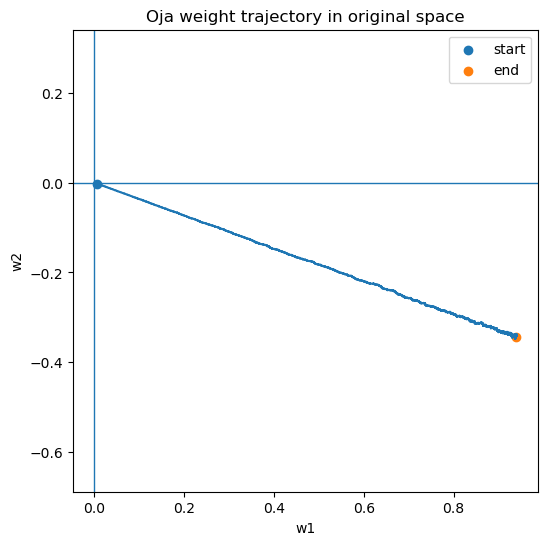

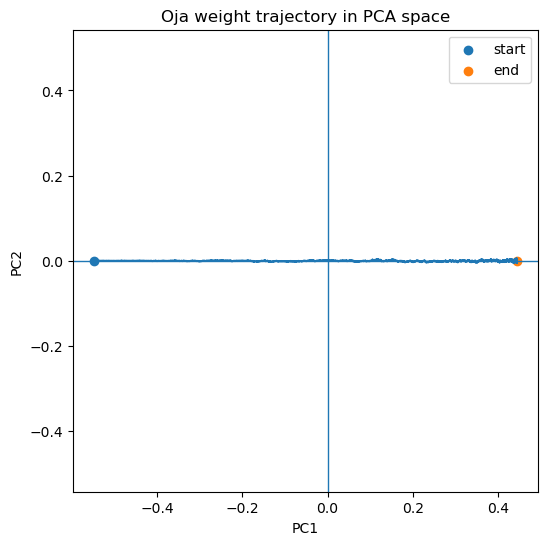

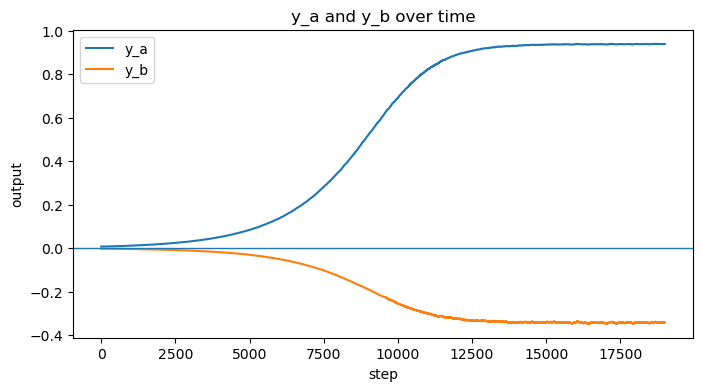

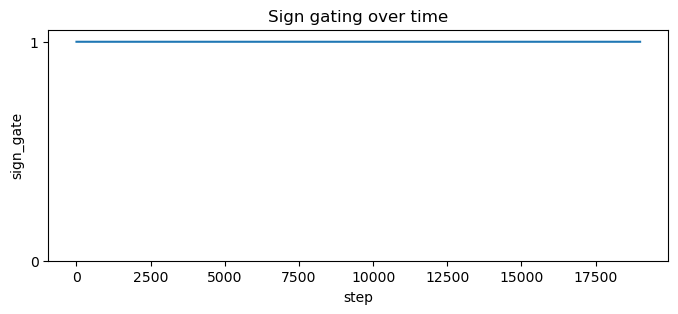

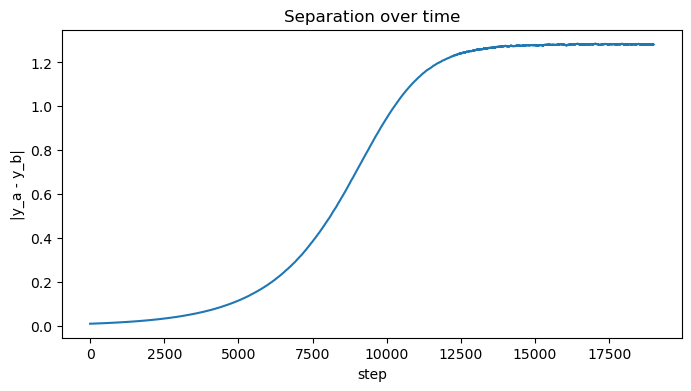

In [3]:
df = statistics.copy()

# ----------------------------
# 1. PCA of the weight trajectory
# ----------------------------
W = df[["w1", "w2"]].to_numpy()

pca = PCA(n_components=2)
W_pca = pca.fit_transform(W)

df["pc1"] = W_pca[:, 0]
df["pc2"] = W_pca[:, 1]

# ----------------------------
# 2. Plot weight trajectory in original space
# ----------------------------
plt.figure(figsize=(6, 6))
plt.plot(df["w1"], df["w2"], linewidth=1.5)
plt.scatter(df["w1"].iloc[0], df["w2"].iloc[0], label="start")
plt.scatter(df["w1"].iloc[-1], df["w2"].iloc[-1], label="end")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("w1")
plt.ylabel("w2")
plt.title("Oja weight trajectory in original space")
plt.legend()
plt.axis("equal")
plt.show()

# ----------------------------
# 3. Plot weight trajectory in PCA space
# ----------------------------
plt.figure(figsize=(6, 6))
plt.plot(df["pc1"], df["pc2"], linewidth=1.5)
plt.scatter(df["pc1"].iloc[0], df["pc2"].iloc[0], label="start")
plt.scatter(df["pc1"].iloc[-1], df["pc2"].iloc[-1], label="end")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Oja weight trajectory in PCA space")
plt.legend()
plt.axis("equal")
plt.show()

# ----------------------------
# 4. Plot y_a and y_b over time
# ----------------------------
plt.figure(figsize=(8, 4))
plt.plot(df["step"], df["y_a"], label="y_a")
plt.plot(df["step"], df["y_b"], label="y_b")
plt.axhline(0, linewidth=1)
plt.xlabel("step")
plt.ylabel("output")
plt.title("y_a and y_b over time")
plt.legend()
plt.show()

# ----------------------------
# 5. Plot sign_gate over time
# ----------------------------
plt.figure(figsize=(8, 3))
plt.plot(df["step"], df["sign_gate"].astype(int), linewidth=1.5)
plt.xlabel("step")
plt.ylabel("sign_gate")
plt.yticks([0, 1])
plt.title("Sign gating over time")
plt.show()

# ----------------------------
# 6. Plot separation over time
# ----------------------------
plt.figure(figsize=(8, 4))
plt.plot(df["step"], df["separation"], linewidth=1.5)
plt.xlabel("step")
plt.ylabel("|y_a - y_b|")
plt.title("Separation over time")
plt.show()

In [ ]:
w = df[["w1","w2"]].iloc[-1].values
target = np.array([1, -1]) / np.sqrt(2)

print(abs(np.dot(w/np.linalg.norm(w), target)))

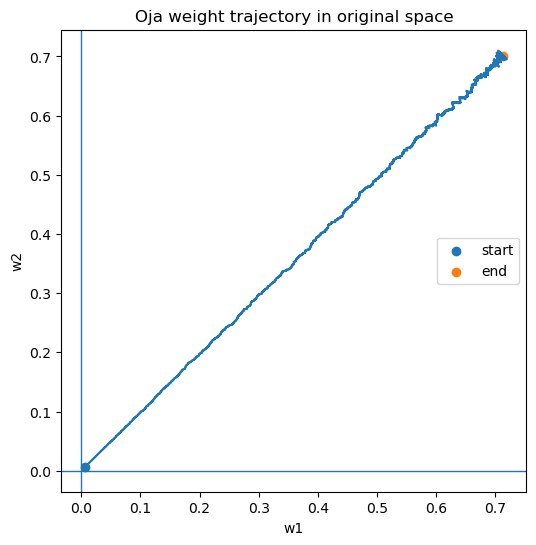

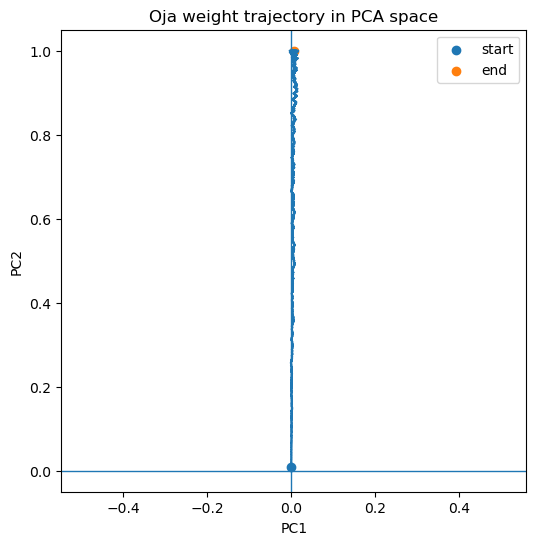

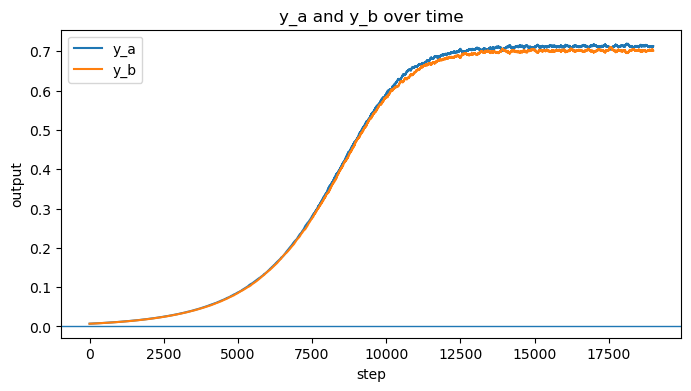

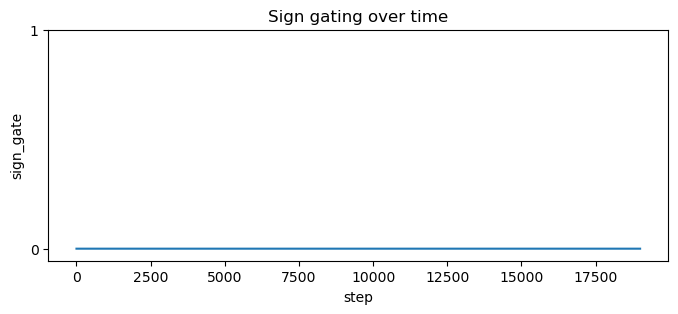

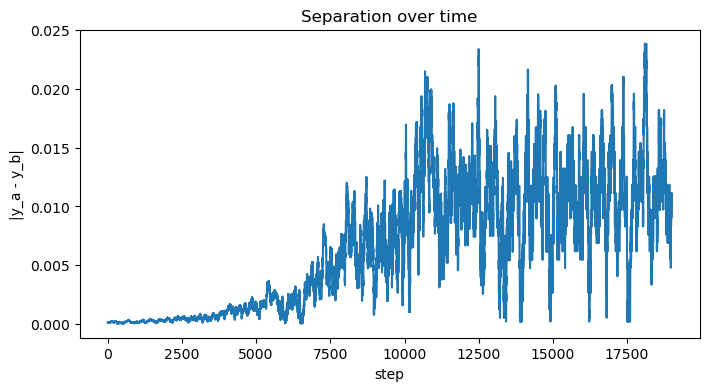

In [17]:
# oja_test = OjaOneHotModel(lr=1e-3)

# device = torch.device("cpu")

# oja_test.to(device)

# train_x = torch.Tensor([
#     [1.0, 0.0],
#     [0.0, 1.0],
# ]).repeat(95,1)

# statistics = oja_test.learn_oja(train_x, epochs=100)
df = statistics.copy()

# # ----------------------------
# # 1. PCA of the weight trajectory
# # ----------------------------
# W = df[["w1", "w2"]].to_numpy()

# pca = PCA(n_components=2)
# W_pca = pca.fit_transform(W)

v1 = np.array([1, -1]) / np.sqrt(2)   # PC1
v2 = np.array([1,  1]) / np.sqrt(2)   # PC2

W = df[["w1", "w2"]].to_numpy()

df["pc1"] = W @ v1
df["pc2"] = W @ v2

# ----------------------------
# 2. Plot weight trajectory in original space
# ----------------------------
plt.figure(figsize=(6, 6))
plt.plot(df["w1"], df["w2"], linewidth=1.5)
plt.scatter(df["w1"].iloc[0], df["w2"].iloc[0], label="start")
plt.scatter(df["w1"].iloc[-1], df["w2"].iloc[-1], label="end")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("w1")
plt.ylabel("w2")
plt.title("Oja weight trajectory in original space")
plt.legend()
plt.axis("equal")
plt.show()

# ----------------------------
# 3. Plot weight trajectory in PCA space
# ----------------------------
plt.figure(figsize=(6, 6))
plt.plot(df["pc1"], df["pc2"], linewidth=1.5)
plt.scatter(df["pc1"].iloc[0], df["pc2"].iloc[0], label="start")
plt.scatter(df["pc1"].iloc[-1], df["pc2"].iloc[-1], label="end")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Oja weight trajectory in PCA space")
plt.legend()
plt.axis("equal")
plt.show()

# ----------------------------
# 4. Plot y_a and y_b over time
# ----------------------------
plt.figure(figsize=(8, 4))
plt.plot(df["step"], df["y_a"], label="y_a")
plt.plot(df["step"], df["y_b"], label="y_b")
plt.axhline(0, linewidth=1)
plt.xlabel("step")
plt.ylabel("output")
plt.title("y_a and y_b over time")
plt.legend()
plt.show()

# ----------------------------
# 5. Plot sign_gate over time
# ----------------------------
plt.figure(figsize=(8, 3))
plt.plot(df["step"], df["sign_gate"].astype(int), linewidth=1.5)
plt.xlabel("step")
plt.ylabel("sign_gate")
plt.yticks([0, 1])
plt.title("Sign gating over time")
plt.show()

# ----------------------------
# 6. Plot separation over time
# ----------------------------
plt.figure(figsize=(8, 4))
plt.plot(df["step"], df["separation"], linewidth=1.5)
plt.xlabel("step")
plt.ylabel("|y_a - y_b|")
plt.title("Separation over time")
plt.show()

Center the inputs

In [4]:
oja_test = OjaOneHotModel(lr=1e-3)

device = torch.device("cpu")

oja_test.to(device)

train_x = torch.Tensor([
    [.5, -.5],
    [-.5, .5],
]).repeat(95,1)

statistics = oja_test.learn_oja(train_x, epochs=100)

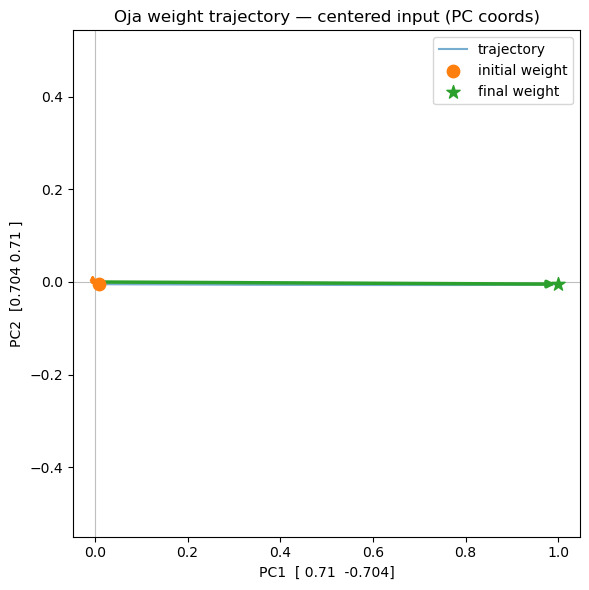

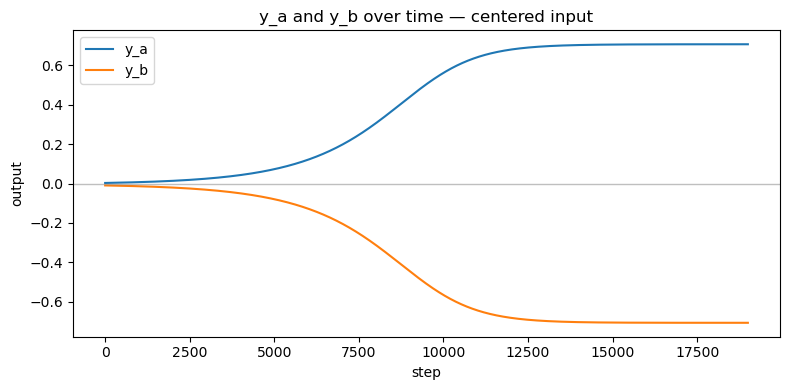

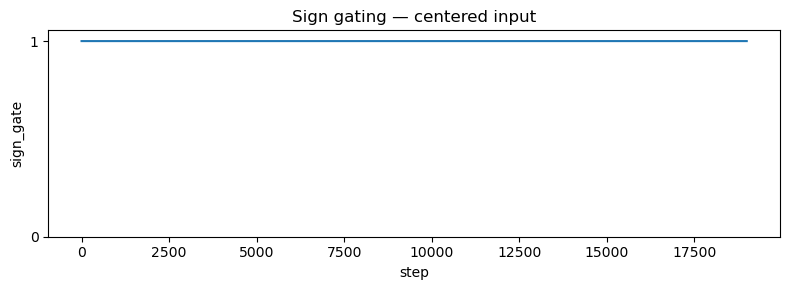

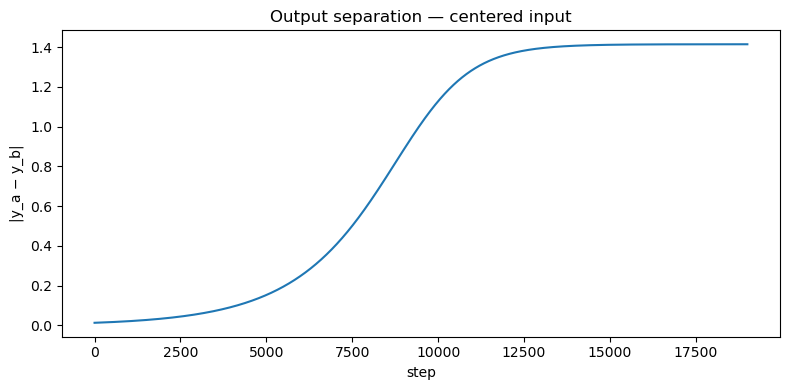

In [5]:
import os
os.makedirs("images/oja-pc-conv", exist_ok=True)

df = statistics.copy()

W = df[["w1", "w2"]].to_numpy()

pca = PCA(n_components=2)
pca.fit(W)
v1 = pca.components_[0]
v2 = pca.components_[1]

df["pc1"] = W @ v1
df["pc2"] = W @ v2

w_init = W[0]
w_final = W[-1]

# ----------------------------
# Weight trajectory in PC space
# ----------------------------
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(df["pc1"], df["pc2"], linewidth=1.5, color="tab:blue", alpha=0.6, label="trajectory", zorder=1)

# Initial weight — dashed arrow from origin, distinct color
ax.annotate(
    "", xy=(df["pc1"].iloc[0], df["pc2"].iloc[0]), xytext=(0, 0),
    arrowprops=dict(arrowstyle="-|>", color="tab:orange", lw=2, linestyle="dashed"),
    zorder=3,
)
ax.scatter(df["pc1"].iloc[0], df["pc2"].iloc[0],
           s=80, color="tab:orange", zorder=4, label="initial weight", marker="o")

# Final weight — solid arrow from origin
ax.annotate(
    "", xy=(df["pc1"].iloc[-1], df["pc2"].iloc[-1]), xytext=(0, 0),
    arrowprops=dict(arrowstyle="-|>", color="tab:green", lw=2.5),
    zorder=3,
)
ax.scatter(df["pc1"].iloc[-1], df["pc2"].iloc[-1],
           s=100, color="tab:green", zorder=4, label="final weight", marker="*")

ax.axhline(0, color="gray", linewidth=0.8, alpha=0.5)
ax.axvline(0, color="gray", linewidth=0.8, alpha=0.5)
ax.set_xlabel(f"PC1  {np.round(v1, 3)}")
ax.set_ylabel(f"PC2  {np.round(v2, 3)}")
ax.set_title("Oja weight trajectory — centered input (PC coords)")
ax.legend()
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.savefig("images/oja-pc-conv/single_run_weight_trajectory.png", dpi=150)
plt.show()

# ----------------------------
# y_a and y_b over time
# ----------------------------
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df["step"], df["y_a"], label="y_a")
ax.plot(df["step"], df["y_b"], label="y_b")
ax.axhline(0, linewidth=1, color="gray", alpha=0.5)
ax.set_xlabel("step")
ax.set_ylabel("output")
ax.set_title("y_a and y_b over time — centered input")
ax.legend()
plt.tight_layout()
plt.savefig("images/oja-pc-conv/single_run_outputs.png", dpi=150)
plt.show()

# ----------------------------
# Sign gating over time
# ----------------------------
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(df["step"], df["sign_gate"].astype(int), linewidth=1.5)
ax.set_xlabel("step")
ax.set_ylabel("sign_gate")
ax.set_yticks([0, 1])
ax.set_title("Sign gating — centered input")
plt.tight_layout()
plt.savefig("images/oja-pc-conv/single_run_sign_gate.png", dpi=150)
plt.show()

# ----------------------------
# Separation over time
# ----------------------------
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df["step"], df["separation"], linewidth=1.5)
ax.set_xlabel("step")
ax.set_ylabel("|y_a − y_b|")
ax.set_title("Output separation — centered input")
plt.tight_layout()
plt.savefig("images/oja-pc-conv/single_run_separation.png", dpi=150)
plt.show()

In [20]:
w = df[["w1","w2"]].iloc[-1].values
target = np.array([1, -1]) / np.sqrt(2)

print(abs(np.dot(w/np.linalg.norm(w), target)))

0.9999999912399137


### Centered input over 50 random seeds

Aggregate 50 centered-input runs to see where Oja's rule converges in weight space and how the target and orthogonal components evolve across random initializations.


In [ ]:
num_runs = 50
centered_epochs = 100
centered_train_x = torch.tensor([
    [0.5, -0.5],
    [-0.5, 0.5],
], device=device).repeat(95, 1)

target_axis = np.array([1.0, -1.0]) / np.sqrt(2.0)
orth_axis = np.array([1.0, 1.0]) / np.sqrt(2.0)

centered_runs = []
for seed in range(num_runs):
    torch.manual_seed(seed)
    np.random.seed(seed)

    run_model = OjaOneHotModel(lr=1e-3).to(device)
    run_df = run_model.learn_oja(centered_train_x, epochs=centered_epochs)
    run_df["run"] = seed

    weights = run_df[["w1", "w2"]].to_numpy()
    run_df["target_component"] = weights @ target_axis
    run_df["orthogonal_component"] = weights @ orth_axis
    run_df["weight_norm"] = np.linalg.norm(weights, axis=1)

    centered_runs.append(run_df)

centered_runs = pd.concat(centered_runs, ignore_index=True)

centered_summary = (
    centered_runs.groupby("step")
    .agg(
        y_a_mean=("y_a", "mean"),
        y_a_std=("y_a", "std"),
        y_b_mean=("y_b", "mean"),
        y_b_std=("y_b", "std"),
        sign_gate_mean=("sign_gate", "mean"),
        sign_gate_std=("sign_gate", "std"),
        separation_mean=("separation", "mean"),
        separation_std=("separation", "std"),
        target_component_mean=("target_component", "mean"),
        target_component_std=("target_component", "std"),
        orthogonal_component_mean=("orthogonal_component", "mean"),
        orthogonal_component_std=("orthogonal_component", "std"),
        weight_norm_mean=("weight_norm", "mean"),
        weight_norm_std=("weight_norm", "std"),
    )
    .fillna(0.0)
    .reset_index()
)
centered_runs.to_csv("data/oja_pc_conv_timeseries_50seeds.csv", index=False)
centered_summary.to_csv("data/oja_pc_conv_summary_timeseries_50seeds.csv", index=False)

centered_final = centered_runs.groupby("run", as_index=False).tail(1).copy()
final_weights = centered_final[["w1", "w2"]].to_numpy()
final_weight_norm = np.linalg.norm(final_weights, axis=1)
centered_final["target_alignment"] = np.abs(final_weights @ target_axis) / np.clip(final_weight_norm, 1e-12, None)

centered_final[["run", "w1", "w2", "target_component", "orthogonal_component", "target_alignment"]].head()


In [ ]:
# --- Final weights in raw 2D weight space ---
early_step = 5_000
centered_early = centered_runs[centered_runs["step"] == early_step].copy()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(
    centered_early["w1"],
    centered_early["w2"],
    s=42,
    c="0.7",
    edgecolors="black",
    linewidth=0.25,
    alpha=0.65,
    label="weights after 5k iters",
    zorder=2,
)
ax.scatter(
    centered_final["w1"],
    centered_final["w2"],
    s=36,
    c="tab:green",
    edgecolors="black",
    linewidth=0.4,
    alpha=0.75,
    label="final weights",
    zorder=3,
)
ax.axhline(0, color="black", linewidth=1, alpha=0.35)
ax.axvline(0, color="black", linewidth=1, alpha=0.35)
pc1_extent = 1.1 * max(
    centered_final["w1"].abs().max(),
    centered_final["w2"].abs().max(),
)
pc1_line = np.array([-pc1_extent, pc1_extent])
ax.plot(pc1_line, -pc1_line, "--", color="tab:orange", linewidth=1.5, alpha=0.8, label="PC1", zorder=1)
ax.set_xlabel("w1")
ax.set_ylabel("w2")
ax.set_title("Final weights — raw 2D weights (50 seeds)")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(centered_final["w1"].min() - 0.2, centered_final["w1"].max() + 0.2)
ax.set_ylim(centered_final["w2"].min() - 0.2, centered_final["w2"].max() + 0.2)
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.savefig("images/oja-pc-conv/final_weights_raw_50seeds.png", dpi=150)
plt.show()

# --- 1D projection onto PC1 (target axis = [1,-1]/√2) ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(
    centered_final["target_component"],
    bins=np.linspace(-1.1, 1.1, 23),
    color="tab:orange",
    edgecolor="black",
    alpha=0.75,
)
ax.axvline(0, color="black", linewidth=1, alpha=0.35)
ax.set_xlabel("PC1  ([1,−1]/√2)  — target component")
ax.set_ylabel("run count")
ax.set_title("Final weights — 1D projection onto PC1 (50 seeds)")
ax.set_xlim(-1.1, 1.1)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig("images/oja-pc-conv/final_weights_pc1_projection_50seeds.png", dpi=150)
plt.show()

centered_final[["w1", "w2", "target_alignment"]].describe()


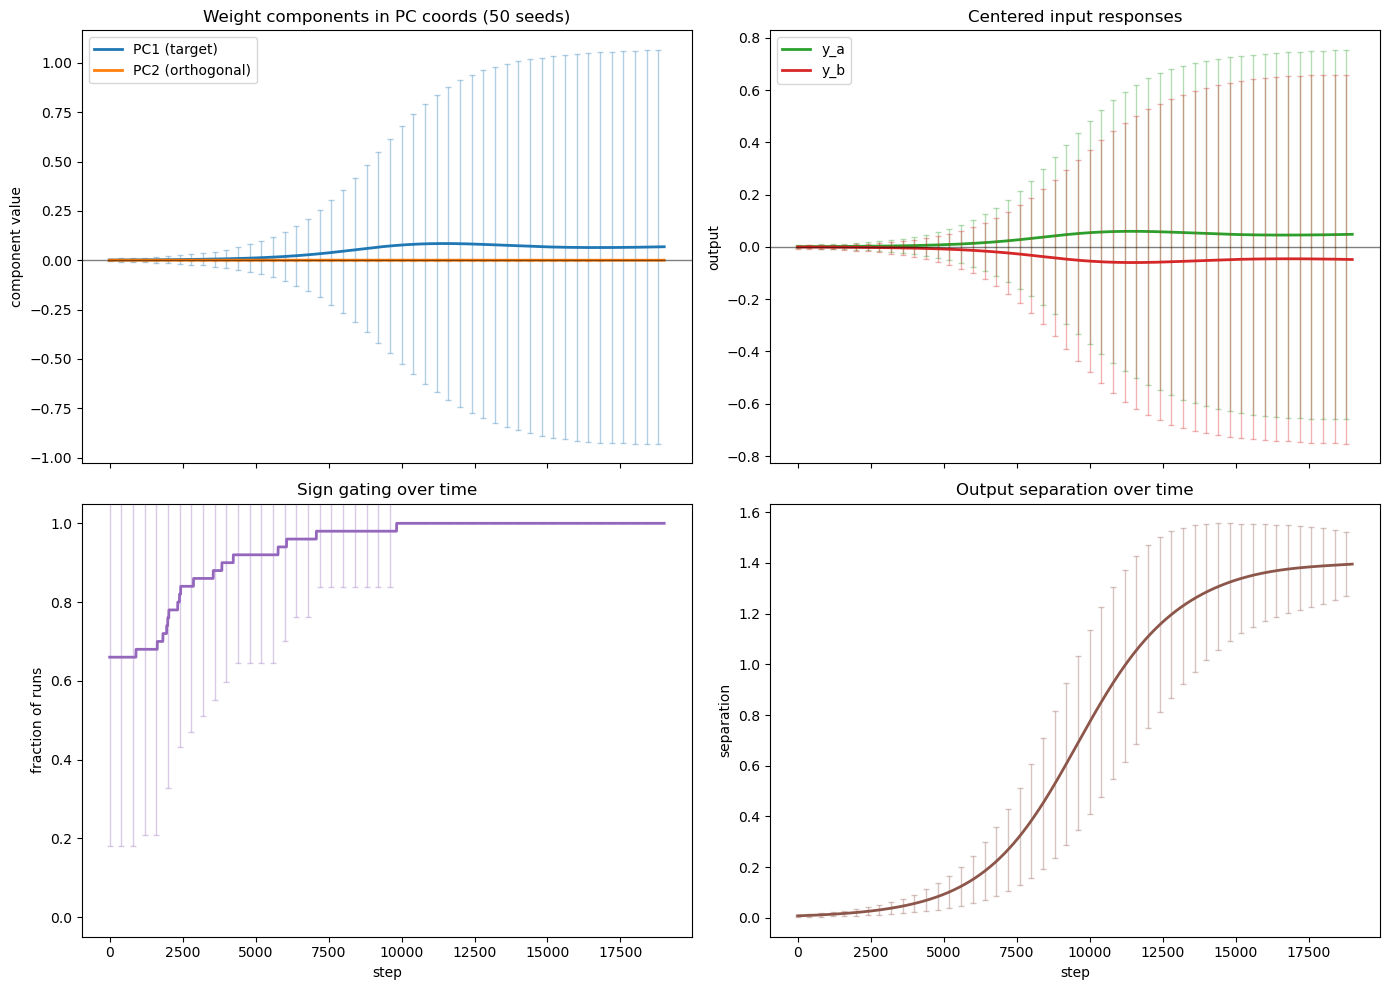

In [8]:
def add_errorbars(ax, summary_df, mean_col, std_col, label, color, stride=400):
    ax.plot(summary_df["step"], summary_df[mean_col], label=label, color=color, linewidth=2)
    sample = summary_df.iloc[::stride]
    ax.errorbar(
        sample["step"],
        sample[mean_col],
        yerr=sample[std_col],
        fmt="none",
        ecolor=color,
        elinewidth=1,
        alpha=0.35,
        capsize=2,
    )

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

add_errorbars(axes[0, 0], centered_summary, "target_component_mean", "target_component_std", "PC1 (target)", "tab:blue")
add_errorbars(axes[0, 0], centered_summary, "orthogonal_component_mean", "orthogonal_component_std", "PC2 (orthogonal)", "tab:orange")
axes[0, 0].axhline(0, color="black", linewidth=1, alpha=0.5)
axes[0, 0].set_ylabel("component value")
axes[0, 0].set_title("Weight components in PC coords (50 seeds)")
axes[0, 0].legend()

add_errorbars(axes[0, 1], centered_summary, "y_a_mean", "y_a_std", "y_a", "tab:green")
add_errorbars(axes[0, 1], centered_summary, "y_b_mean", "y_b_std", "y_b", "tab:red")
axes[0, 1].axhline(0, color="black", linewidth=1, alpha=0.5)
axes[0, 1].set_ylabel("output")
axes[0, 1].set_title("Centered input responses")
axes[0, 1].legend()

add_errorbars(axes[1, 0], centered_summary, "sign_gate_mean", "sign_gate_std", "sign_gate", "tab:purple")
axes[1, 0].set_ylim(-0.05, 1.05)
axes[1, 0].set_xlabel("step")
axes[1, 0].set_ylabel("fraction of runs")
axes[1, 0].set_title("Sign gating over time")

add_errorbars(axes[1, 1], centered_summary, "separation_mean", "separation_std", "|y_a - y_b|", "tab:brown")
axes[1, 1].set_xlabel("step")
axes[1, 1].set_ylabel("separation")
axes[1, 1].set_title("Output separation over time")

plt.tight_layout()
plt.savefig("images/oja-pc-conv/summary_timeseries_50seeds.png", dpi=150)
plt.show()


## 2. Embedding layer

We now examine the behaviour with embedding layer added.

In [ ]:
oja_test = OjaEmbedModel(lr=1e-3)

device = torch.device("cpu")

oja_test.to(device)

train_x = data.make_behavioral_experiment_training_data(distractor_strength=.975)[0]

# filter data to always contain category context
train_x = train_x[1][:20*19]
statistics = oja_test.learn_oja(train_x)

In [ ]:
df = statistics.copy()

# ----------------------------
# 1. PCA of the weight trajectory
# ----------------------------
W = df[["w1", "w2"]].to_numpy()

pca = PCA(n_components=2)
W_pca = pca.fit_transform(W)

df["pc1"] = W_pca[:, 0]
df["pc2"] = W_pca[:, 1]

# ----------------------------
# 2. Plot weight trajectory in original space
# ----------------------------
plt.figure(figsize=(6, 6))
plt.plot(df["w1"], df["w2"], linewidth=1.5)
plt.scatter(df["w1"].iloc[0], df["w2"].iloc[0], label="start")
plt.scatter(df["w1"].iloc[-1], df["w2"].iloc[-1], label="end")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("w1")
plt.ylabel("w2")
plt.title("Oja weight trajectory in original space")
plt.legend()
plt.axis("equal")
plt.show()

# ----------------------------
# 3. Plot weight trajectory in PCA space
# ----------------------------
plt.figure(figsize=(6, 6))
plt.plot(df["pc1"], df["pc2"], linewidth=1.5)
plt.scatter(df["pc1"].iloc[0], df["pc2"].iloc[0], label="start")
plt.scatter(df["pc1"].iloc[-1], df["pc2"].iloc[-1], label="end")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Oja weight trajectory in PCA space")
plt.legend()
plt.axis("equal")
plt.show()

# ----------------------------
# 4. Plot y_a and y_b over time
# ----------------------------
plt.figure(figsize=(8, 4))
plt.plot(df["step"], df["y_a"], label="y_a")
plt.plot(df["step"], df["y_b"], label="y_b")
plt.axhline(0, linewidth=1)
plt.xlabel("step")
plt.ylabel("output")
plt.title("y_a and y_b over time")
plt.legend()
plt.show()

# ----------------------------
# 5. Plot sign_gate over time
# ----------------------------
plt.figure(figsize=(8, 3))
plt.plot(df["step"], df["sign_gate"].astype(int), linewidth=1.5)
plt.xlabel("step")
plt.ylabel("sign_gate")
plt.yticks([0, 1])
plt.title("Sign gating over time")
plt.show()

# ----------------------------
# 6. Plot separation over time
# ----------------------------
plt.figure(figsize=(8, 4))
plt.plot(df["step"], df["separation"], linewidth=1.5)
plt.xlabel("step")
plt.ylabel("|y_a - y_b|")
plt.title("Separation over time")
plt.show()

In [ ]:
w = df[["w1","w2"]].iloc[-1].values
target = np.array([1, -1]) / np.sqrt(2)

print(abs(np.dot(w/np.linalg.norm(w), target)))

## 3. Reintegration into ISC model

In [13]:
from pathlib import Path

results_path = Path('data/oja_baseline_comparison.csv')
lc_path = Path('data/oja_learning_curves.csv')

if lc_path.exists():
    lc_df = pd.read_csv(lc_path)
else:
    old_error_data = pd.read_csv(results_path)
    old_error_data = old_error_data[old_error_data['architecture'] == 'ISC']
    error_data = []
    lc_data = []
    num_epochs = 40

    print('Now training Hebbian Oja model...')
    hebb_errors, hebb_lc = run_hebbian_experiment(num_epochs=num_epochs, alpha=0., track_learning_curves=True)
    error_data += hebb_errors
    lc_data += hebb_lc
    print('\t...finished!\n')

    error_data = pd.concat(error_data, axis=0, ignore_index=True)
    error_data = pd.concat([error_data, old_error_data], axis=0, ignore_index=True)
    error_data.to_csv(results_path, index=False)

    # force bce to plain Python float before concat to avoid object-dtype 0-d arrays
    for df in lc_data:
        df['bce'] = [float(v) for v in df['bce']]

    lc_df = pd.concat(lc_data, axis=0, ignore_index=True)
    lc_df.to_csv(lc_path, index=False)

lc_df['epoch'] = lc_df['epoch'].astype(int)
lc_df['bce'] = lc_df['bce'].astype(float)

Now training Hebbian Oja model...
	...finished!



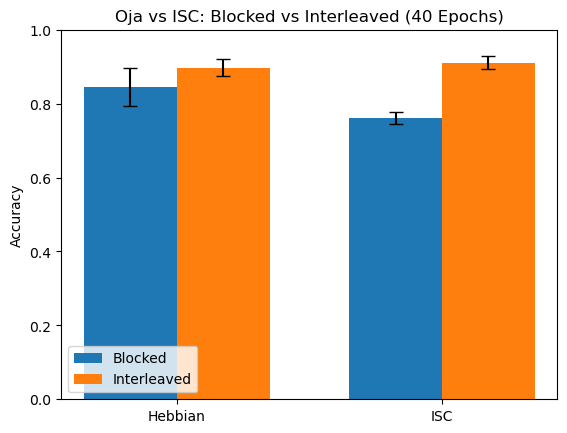

In [17]:
df = pd.read_csv('data/oja_baseline_comparison.csv')

model_means = df.groupby(['architecture', 'condition', 'model'])['acc'].mean()
stats = model_means.groupby(['architecture', 'condition']).agg(['mean', 'std'])

def get_mean_std(arch, cond):
    row = stats.loc[(arch, cond)]
    return row['mean'], row['std']

hebbian_blocked_mean,     hebbian_blocked_std     = get_mean_std("Hebbian", "blocked")
hebbian_interleaved_mean, hebbian_interleaved_std = get_mean_std("Hebbian", "interleaved")
isc_blocked_mean,         isc_blocked_std         = get_mean_std("ISC", "blocked")
isc_interleaved_mean,     isc_interleaved_std     = get_mean_std("ISC", "interleaved")

models = ["Hebbian", "ISC"]
blocked         = [hebbian_blocked_mean,      isc_blocked_mean]
blocked_err     = [hebbian_blocked_std,       isc_blocked_std]
interleaved     = [hebbian_interleaved_mean,  isc_interleaved_mean]
interleaved_err = [hebbian_interleaved_std,   isc_interleaved_std]

x = np.arange(len(models))
width = 0.35

plt.figure()
plt.bar(x - width/2, blocked,     width, label="Blocked",     yerr=blocked_err,     capsize=5)
plt.bar(x + width/2, interleaved, width, label="Interleaved", yerr=interleaved_err, capsize=5)

plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.title("Oja vs ISC: Blocked vs Interleaved (40 Epochs)")
plt.legend()
plt.ylim(0, 1)
plt.savefig('images/ema/oja_isc_baseline')
plt.show()

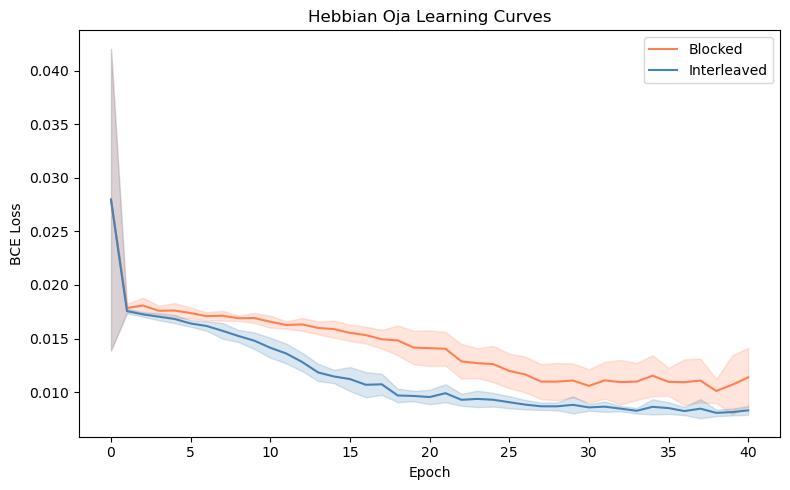

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = {'interleaved': 'steelblue', 'blocked': 'coral'}
for condition, group in lc_df.groupby('condition'):
    mean = group.groupby('epoch')['bce'].mean()
    std  = group.groupby('epoch')['bce'].std().fillna(0.0)
    ax.plot(mean.index, mean.values, label=condition.capitalize(), color=colors[condition])
    ax.fill_between(mean.index, mean - std, mean + std, alpha=0.2, color=colors[condition])

ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('Hebbian Oja Learning Curves')
ax.legend()
plt.tight_layout()
plt.savefig('images/ema/oja_learning_curves.png', dpi=150)
plt.show()

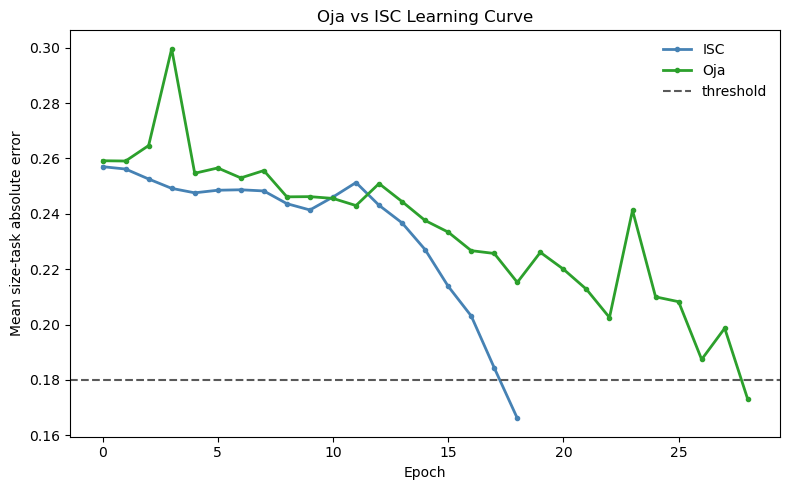

Saved learning-curve data to data/oja_vs_isc_learning_curve_bce.csv
Saved learning-curve figure to images/ema/oja_vs_isc_learning_curve.png


In [15]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from experimental_setups.hebbian_model.experiment import prepare_experiment_data
from experimental_setups.hebbian_model.oja_variant_model import SimpleHebbianModel as OjaModel
from experimental_setups.isc_model.model import ISCModel, load_isc_models

OJA_ISC_LC_THRESHOLD = 0.18
OJA_ISC_LC_MAX_EPOCHS = 80
OJA_ISC_LC_ALPHA = float(np.linspace(0.05, 1, 30)[25])
OJA_ISC_LC_BATCH_SIZE = 38
OJA_ISC_LC_SEED = 0
OJA_ISC_LC_DATA_PATH = Path('data/oja_vs_isc_learning_curve_bce.csv')
OJA_ISC_LC_FIGURE_PATH = Path('images/ema/oja_vs_isc_learning_curve.png')

random.seed(OJA_ISC_LC_SEED)
np.random.seed(OJA_ISC_LC_SEED)
torch.manual_seed(OJA_ISC_LC_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(OJA_ISC_LC_SEED)

train_x, train_y = prepare_experiment_data()
device = train_y.device
base_model = load_isc_models(1, device=device)[0]


def calc_bhvsim_model_error(model, train_x, train_y):
    with torch.no_grad():
        errors = torch.abs(model(train_x) - train_y)[:, [2541, 2542]].mean(axis=-1)
    return errors.cpu().numpy()


def calc_bce_loss(model, train_x, train_y):
    with torch.no_grad():
        logits = model(train_x, take_sigmoid=False)
        return float(model.loss_fn(logits, train_y).detach().cpu().item())


def learning_curve_row(model_name, epoch, model):
    size_errors = calc_bhvsim_model_error(model, train_x, train_y)
    return {
        'model': model_name,
        'epoch': epoch,
        'size_error': float(size_errors.mean()),
        'bce_loss': calc_bce_loss(model, train_x, train_y),
        'threshold': OJA_ISC_LC_THRESHOLD,
        'source': 'experimental_setups.hebbian_model.bhvsim_experiment',
        'condition': 'blocked_train' if model_name == 'Oja' else 'same_train_set',
        'alpha': OJA_ISC_LC_ALPHA if model_name == 'Oja' else np.nan,
        'batch_size': OJA_ISC_LC_BATCH_SIZE,
    }


def train_learning_curve(model_name, model, train_one_epoch):
    rows = [learning_curve_row(model_name, 0, model)]
    while rows[-1]['size_error'] > OJA_ISC_LC_THRESHOLD and rows[-1]['epoch'] < OJA_ISC_LC_MAX_EPOCHS:
        train_one_epoch(model)
        rows.append(learning_curve_row(model_name, rows[-1]['epoch'] + 1, model))
    return pd.DataFrame(rows)


isc_learning_curve_model = ISCModel(
    device=device,
    num_tasks=5,
    num_task_context_units=16,
    num_context_dependent_hidden_units=128,
)
isc_learning_curve_model.load_old_model_weights(
    base_model.state_dict(),
    use_old_size_starting_point=True,
)
isc_curve = train_learning_curve(
    'ISC',
    isc_learning_curve_model,
    lambda model: model.train(train_x, train_y, epochs=1, batch_size=OJA_ISC_LC_BATCH_SIZE),
)

oja_learning_curve_model = OjaModel(
    device=device,
    num_tasks=5,
    num_context_dependent_hidden_units=128,
    alpha_ema=OJA_ISC_LC_ALPHA,
)
oja_learning_curve_model.load_old_model_weights(base_model.state_dict())
oja_curve = train_learning_curve(
    'Oja',
    oja_learning_curve_model,
    lambda model: model.train(
        train_x,
        train_y,
        epochs=1,
        batch_size=OJA_ISC_LC_BATCH_SIZE,
        is_blocked=True,
    ),
)

learning_curve_data = pd.concat([isc_curve, oja_curve], axis=0, ignore_index=True)
OJA_ISC_LC_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
learning_curve_data.to_csv(OJA_ISC_LC_DATA_PATH, index=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = {'ISC': 'steelblue', 'Oja': 'tab:green'}
for model_name, model_data in learning_curve_data.groupby('model', sort=False):
    ax.plot(
        model_data['epoch'],
        model_data['size_error'],
        marker='o',
        markersize=3,
        linewidth=2,
        label=model_name,
        color=colors.get(model_name),
    )
ax.axhline(OJA_ISC_LC_THRESHOLD, color='0.35', linestyle='--', linewidth=1.5, label='threshold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Mean size-task absolute error')
ax.set_title('Oja vs ISC Learning Curve')
ax.legend(frameon=False)
fig.tight_layout()
OJA_ISC_LC_FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OJA_ISC_LC_FIGURE_PATH, dpi=150)
plt.show()

print(f'Saved learning-curve data to {OJA_ISC_LC_DATA_PATH}')
print(f'Saved learning-curve figure to {OJA_ISC_LC_FIGURE_PATH}')


In [ ]:
from scipy.stats import ttest_ind

# Stats only: use validation accuracy exactly as stored in data/oja_baseline_comparison.csv.
# The MAE hypothesis blocked > interleaved maps to validation accuracy blocked < interleaved.
df = pd.read_csv('data/oja_baseline_comparison.csv')
df = df[df['architecture'].isin(['Hebbian', 'ISC'])].copy()

seed_acc = (
    df.groupby(['architecture', 'condition', 'model'], as_index=False)['acc']
    .mean()
)


def acc_values(architecture, condition):
    return seed_acc[
        (seed_acc['architecture'] == architecture) &
        (seed_acc['condition'] == condition)
    ]['acc'].to_numpy()


stat_rows = []
for architecture in ['ISC', 'Hebbian']:
    blocked = acc_values(architecture, 'blocked')
    interleaved = acc_values(architecture, 'interleaved')
    result = ttest_ind(blocked, interleaved, equal_var=False, alternative='less')
    stat_rows.append({
        'test': f'{architecture} blocked < {architecture} interleaved',
        'comparison_type': 'within_model_curriculum',
        'alternative': 'blocked accuracy < interleaved accuracy',
        'mean_acc_blocked': blocked.mean(),
        'mean_acc_interleaved': interleaved.mean(),
        'mean_acc_diff_blocked_minus_interleaved': blocked.mean() - interleaved.mean(),
        'p_value': result.pvalue,
    })

for condition in ['blocked', 'interleaved']:
    isc = acc_values('ISC', condition)
    hebbian = acc_values('Hebbian', condition)
    result = ttest_ind(isc, hebbian, equal_var=False, alternative='two-sided')
    stat_rows.append({
        'test': f'ISC {condition} vs Hebbian {condition}',
        'comparison_type': 'cross_model_curriculum_matched',
        'alternative': 'ISC accuracy != Hebbian accuracy',
        'mean_acc_isc': isc.mean(),
        'mean_acc_hebbian': hebbian.mean(),
        'mean_acc_diff_isc_minus_hebbian': isc.mean() - hebbian.mean(),
        'p_value': result.pvalue,
    })

oja_val_acc_tests = pd.DataFrame(stat_rows)
oja_val_acc_tests.to_csv('data/oja_baseline_val_acc_tests.csv', index=False)
display(oja_val_acc_tests)


In [ ]:
import numpy as np
from experimental_setups.hebbian_model.experiment import prepare_experiment_data

train_x, _ = prepare_experiment_data()

# prepare_experiment_data already orders the two category blocks contiguously;
# the blocked trainer only shuffles within each half, so this lag-1 value is invariant.
blocked_category = train_x[1][:, 0].detach().cpu().numpy().astype(float)
lag1_blocked_autocorr = np.corrcoef(blocked_category[:-1], blocked_category[1:])[0, 1]
adjacent_same_block_rate = np.mean(blocked_category[:-1] == blocked_category[1:])

print(f'lag-1 blocked category autocorrelation: {lag1_blocked_autocorr:.4f}')
print(f'adjacent same-block rate: {adjacent_same_block_rate:.4f}')
